# Inference with clouds aware floods segmentation model

* **Last Modified**: 30-11-2023
* **Authors**: Gonzalo Mateo-García, Enrique Portalés-Julià
---

This notebook shows how to load and make inferences with the clouds aware flood segmentation model proposed in:

> E. Portalés-Julià, G. Mateo-García, C. Purcell, and L. Gómez-Chova [Global flood extent segmentation in optical satellite images](https://www.nature.com/articles/s41598-023-47595-7). _Scientific Reports 13, 20316_ (2023). DOI: 10.1038/s41598-023-47595-7.

With this model we are able to correctly classify land/water in partially cloud covered places and over thin and semi-transparent clouds.

Install the `ml4floods` package if not installed

```
!pip install ml4floods
```

## ml4floods trained model

The following scheme details the training and inference workflow of the WorldFloods multioutput models. We will load the trained model into a function that outputs a 3-class prediction by applying prediction rule detailed below:

![prediction_rule](prediction_rule.png)



In [1]:
import os
from huggingface_hub import hf_hub_download, hf_hub_url

import torch
import numpy as np
from shapely.geometry import shape

from georeader.rasterio_reader import RasterioReader
from georeader.geotensor import GeoTensor
from georeader.readers import ee_query
from georeader.readers import ee_image
from datetime import datetime
from georeader import plot

import ee
from ml4floods.visualization import plot_utils
import matplotlib.pyplot as plt

COLORS_PRED = np.array([[0, 0, 0], # 0: invalid
                       [139, 64, 0], # 1: land
                       [0, 0, 240], # 2: water
                       [220, 220, 220], # 3: cloud
                       [60, 85, 92]], # 5: flood_trace
                    dtype=np.float32) / 255

## Load trained model

Read the trained model from our [HuggingFace repo](https://huggingface.co/isp-uv-es/ml4floods). We will load the *Unet multioutput S2-to-L8* model of the [paper](https://www.nature.com/articles/s41598-023-47595-7). In case you want to load a different model set the `experiment_name` variable below to according to:

* Unet multioutput - `WF2_unetv2_all`
* Unet multioutput S2-to-L8 - `WF2_unetv2_bgriswirs`
* Unet multioutput RGBNIR - `WF2_unetv2_rgbi`

![metrics_ml4floods](metrics_ml4floods.png)

In [2]:
experiment_name = "WF2_unetv2_bgriswirs"
subfolder_local = f"models/{experiment_name}"
config_file = hf_hub_download(repo_id="isp-uv-es/ml4floods",subfolder=subfolder_local, filename="config.json",
                              local_dir=".", local_dir_use_symlinks=False)
model_file = hf_hub_download(repo_id="isp-uv-es/ml4floods",subfolder=subfolder_local, filename="model.pt",
                              local_dir=".", local_dir_use_symlinks=False)

models/WF2_unetv2_bgriswirs/config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

model.pt:   0%|          | 0.00/31.1M [00:00<?, ?B/s]

In [3]:
from ml4floods.scripts.inference import load_inference_function
from ml4floods.models.model_setup import get_channel_configuration_bands

inference_function, config = load_inference_function(subfolder_local, device_name = 'cpu', max_tile_size=1024,
                                                     th_water=0.7, th_brightness=3500,
                                                     distinguish_flood_traces=True)

channel_configuration = config['data_params']['channel_configuration']
channels  = get_channel_configuration_bands(channel_configuration, collection_name='S2')

Loaded model weights: models/WF2_unetv2_bgriswirs/model.pt
Getting model inference function


In [4]:
def predict(input_tensor, channels = [1, 2, 3, 7, 11, 12] ):
    input_tensor = input_tensor.astype(np.float32)
    input_tensor = input_tensor[channels]
    torch_inputs = torch.tensor(np.nan_to_num(input_tensor))
    return inference_function(torch_inputs)

## Inference on S2 data from the *WorldFloodsv2* dataset

The *WorldFloodsv2* dataset is stored in this [HuggingFace repository](https://huggingface.co/datasets/isp-uv-es/WorldFloodsv2). We'll grab a S2 image from the dataset and run inference on them.

In [5]:
# Select image to use
subset = "test"
filename = "EMSR264_18MIANDRIVAZODETAIL_DEL_v2"

s2url = hf_hub_url(repo_id="isp-uv-es/WorldFloodsv2",
                   subfolder=f"{subset}/S2", filename=f"{filename}.tif",
                   repo_type="dataset")

channels  = get_channel_configuration_bands(channel_configuration, collection_name='S2')

s2rst = RasterioReader(s2url).isel({"band": channels})
s2rst = s2rst.load()
prediction_test, prediction_test_cont  = predict(s2rst.values, channels = list(range(len(channels))))
prediction_test_raster = GeoTensor(prediction_test.numpy(), transform=s2rst.transform,
                                   fill_value_default=0, crs=s2rst.crs)
prediction_test_raster

 
         Transform: | 10.00, 0.00, 537430.00|
| 0.00,-10.00, 7844180.00|
| 0.00, 0.00, 1.00|
         Shape: (1313, 1530)
         Resolution: (10.0, 10.0)
         Bounds: (537430.0, 7831050.0, 552730.0, 7844180.0)
         CRS: EPSG:32738
         fill_value_default: 0
        

Text(0.5, 1.0, 'test/EMSR264_18MIANDRIVAZODETAIL_DEL_v2 floodmap')

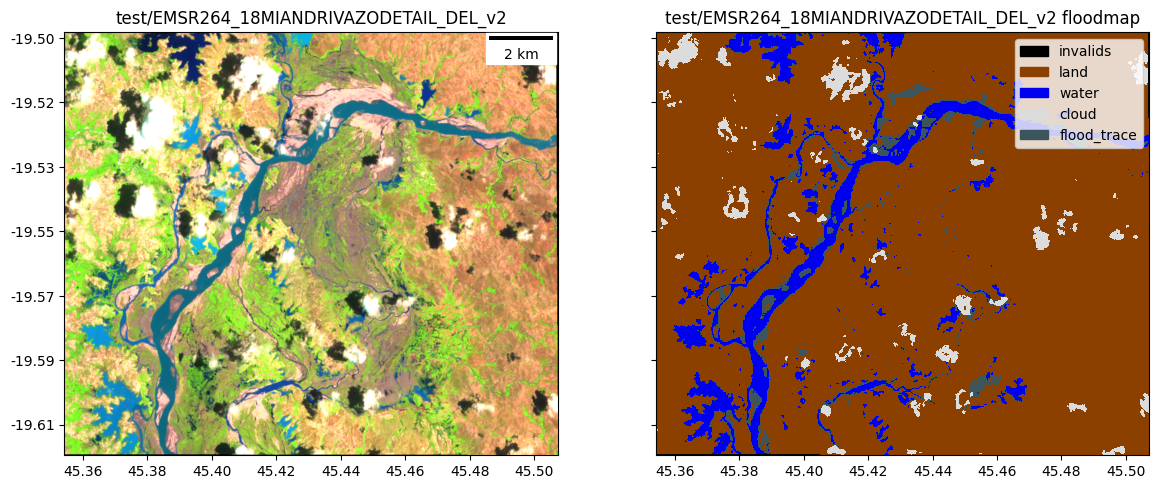

In [6]:
fig, ax = plt.subplots(1,2,figsize=(14,7), sharey=True)

plot.show((s2rst.isel({"band": [4,3,2]})/3_500).clip(0,1), ax=ax[0], add_scalebar=True)
ax[0].set_title(f"{subset}/{filename}")


plot.plot_segmentation_mask(prediction_test_raster, COLORS_PRED, ax=ax[1],
                            interpretation_array=["invalids", "land", "water", "cloud", "flood_trace"])

ax[1].set_title(f"{subset}/{filename} floodmap")

## Inference on a new Sentinel-2 image

### Download a Sentinel-2 image

In [9]:
ee.Authenticate()

Enter verification code:  4/1AfJohXkfopCLZfR-xVjA44ZxQYdPAtqJzelYGl8lPJOHZRDPvnJsDiL4U-4



Successfully saved authorization token.


In [7]:
# ee.Authenticate()
ee.Initialize()

aoi = shape({'type': 'Polygon',
 'coordinates': [[[153.20789834941638, -28.75874177524779],
          [153.20789834941638, -28.91332819718112],
          [153.38848611797107, -28.91332819718112],
          [153.38848611797107, -28.75874177524779]]]})

In [8]:
s2data = ee_query.query(aoi, datetime(2022,3,1), datetime(2022,3,2), producttype="S2")
bands_s2 = get_channel_configuration_bands(channel_configuration, collection_name='S2',as_string=True)
asset_id = f"{s2data.iloc[0].collection_name}/{s2data.iloc[0].gee_id}"
geom = s2data.iloc[0].geometry.intersection(aoi)
postflood = ee_image.export_image_getpixels(asset_id, geom, proj=s2data.iloc[0].proj,bands_gee=bands_s2)
postflood

/home/gonzalo/mambaforge/envs/ml4floods2/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non

 
         Transform: | 10.00, 0.00, 520260.00|
| 0.00,-10.00, 6818730.00|
| 0.00, 0.00, 1.00|
         Shape: (6, 1717, 1766)
         Resolution: (10.0, 10.0)
         Bounds: (520260.0, 6801560.0, 537920.0, 6818730.0)
         CRS: EPSG:32756
         fill_value_default: 0.0
        

### Run inference

In [9]:
%%time

prediction_postflood, prediction_postflood_cont  = predict(postflood.values, channels = list(range(len(bands_s2))))
prediction_postflood_raster = GeoTensor(prediction_postflood.numpy(), transform=postflood.transform,
                                        fill_value_default=0, crs=postflood.crs)

CPU times: user 1min 30s, sys: 15.9 s, total: 1min 46s
Wall time: 14 s


### Plot results

Text(0.5, 1.0, '2022-03-02 floodmap')

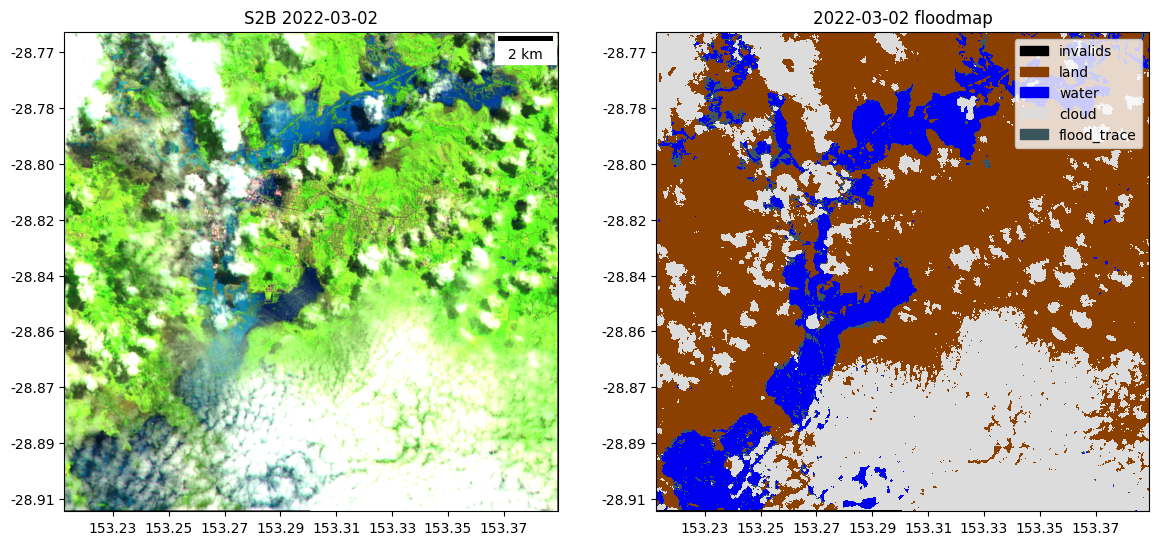

In [10]:
fig, ax = plt.subplots(1,2,figsize=(14,7))

plot.show((postflood.isel({"band": [4,3,2]})/3_500).clip(0,1), ax=ax[0], add_scalebar=True)
ax[0].set_title(f"{s2data.iloc[0].satellite} {s2data.iloc[0].solarday}")


plot.plot_segmentation_mask(prediction_postflood_raster, COLORS_PRED, ax=ax[1],
                            interpretation_array=["invalids", "land", "water", "cloud", "flood_trace"])


ax[1].set_title(f"{s2data.iloc[0].solarday} floodmap")


## Inference on a new Landsat image

### Download a Landsat image

In [11]:
%%time

satdata = ee_query.query(aoi, datetime(2022,4,4), datetime(2022,4,5), producttype="Landsat")
bands_landsat = get_channel_configuration_bands(channel_configuration, collection_name='Landsat',as_string=True)
asset_id = f"{satdata.iloc[0].collection_name}/{satdata.iloc[0].gee_id}"
geom = satdata.iloc[0].geometry.intersection(aoi)
postfloodl8 = ee_image.export_image_getpixels(asset_id, geom, proj=satdata.iloc[0].proj,bands_gee=bands_landsat)
postfloodl8.values *= 10000
postfloodl8

/home/gonzalo/mambaforge/envs/ml4floods2/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


CPU times: user 148 ms, sys: 15.2 ms, total: 163 ms
Wall time: 4.47 s


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


 
         Transform: | 30.00, 0.00, 520245.00|
| 0.00,-30.00,-3181245.00|
| 0.00, 0.00, 1.00|
         Shape: (6, 573, 590)
         Resolution: (30.0, 30.0)
         Bounds: (520245.0, -3198435.0, 537945.0, -3181245.0)
         CRS: EPSG:32656
         fill_value_default: -inf
        

### Run inference

In [12]:
%%time

prediction_postfloodl8, prediction_postflood_contl8  = predict(postfloodl8.values, channels = list(range(len(bands_s2))))
prediction_postfloodl8_raster = GeoTensor(prediction_postfloodl8.numpy(), transform=postfloodl8.transform,
                                        fill_value_default=0, crs=postfloodl8.crs)
prediction_postfloodl8_raster

CPU times: user 9.22 s, sys: 1.38 s, total: 10.6 s
Wall time: 1.38 s


 
         Transform: | 30.00, 0.00, 520245.00|
| 0.00,-30.00,-3181245.00|
| 0.00, 0.00, 1.00|
         Shape: (573, 590)
         Resolution: (30.0, 30.0)
         Bounds: (520245.0, -3198435.0, 537945.0, -3181245.0)
         CRS: EPSG:32656
         fill_value_default: 0
        

### Plot results

Text(0.5, 1.0, '2022-04-05 floodmap')

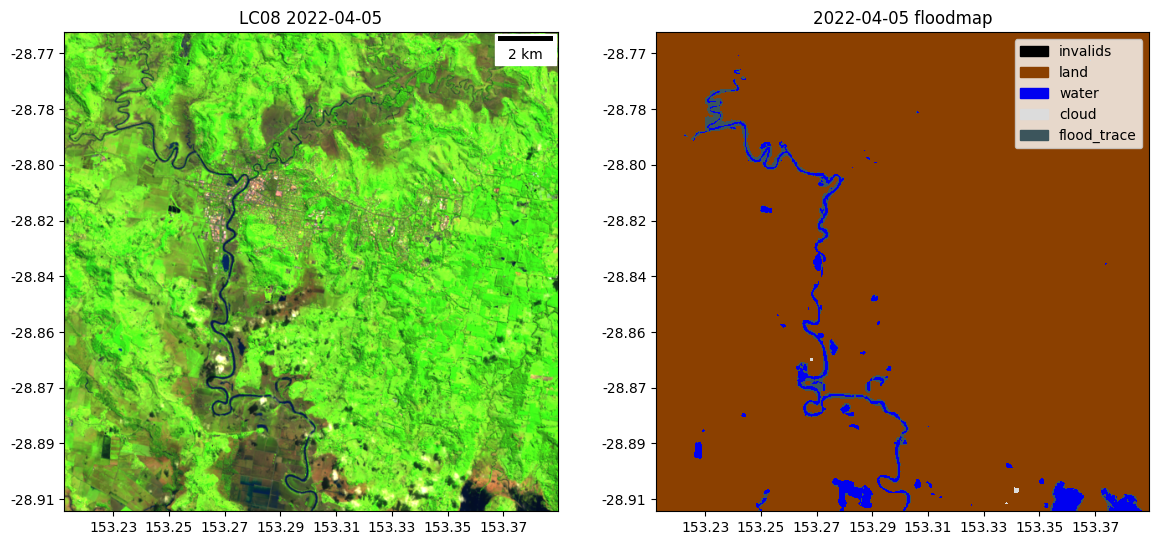

In [13]:
fig, ax = plt.subplots(1,2,figsize=(14,7))

plot.show((postfloodl8.isel({"band": [4,3,2]})/3_500).clip(0,1), ax=ax[0], add_scalebar=True)
ax[0].set_title(f"{satdata.iloc[0].satellite} {satdata.iloc[0].solarday}")


plot.plot_segmentation_mask(prediction_postfloodl8_raster, COLORS_PRED, ax=ax[1],
                            interpretation_array=["invalids", "land", "water", "cloud", "flood_trace"])

ax[1].set_title(f"{satdata.iloc[0].solarday} floodmap")

## Licence
The ML4Floods package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *WorldFloods* database and all pre-trained models are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt). For using the models in comercial pipelines written consent by the authors must be provided.

The Ml4Floods notebooks and docs are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt).

 If you find this work useful please cite:
```
@article{portales-julia_global_2023,
	title = {Global flood extent segmentation in optical satellite images},
	volume = {13},
	issn = {2045-2322},
	doi = {10.1038/s41598-023-47595-7},
	number = {1},
	urldate = {2023-11-30},
	journal = {Scientific Reports},
	author = {Portalés-Julià, Enrique and Mateo-García, Gonzalo and Purcell, Cormac and Gómez-Chova, Luis},
	month = nov,
	year = {2023},
	pages = {20316},
}
```

## Acknowledgments

This research has been supported by the DEEPCLOUD project (PID2019-109026RB-I00) funded by the Spanish Ministry of Science and Innovation (MCIN/AEI/10.13039/501100011033) and the European Union (NextGenerationEU).

<img width="300" title="DEEPCLOUD project (PID2019-109026RB-I00, University of Valencia) funded by MCIN/AEI/10.13039/501100011033." alt="DEEPCLOUD project (PID2019-109026RB-I00, University of Valencia) funded by MCIN/AEI/10.13039/501100011033." src="https://www.uv.es/chovago/logos/logoMICIN.jpg">